# Exploratory Data Analysis

=== INFO DATA TRAINING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None

=== 5 BARIS PERTAMA DATA TRAINING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918



=== PENGECEKAN MISSING VALUES ===
Tidak ada missing values pada Data Training. Data bersih.


/tmp/ipykernel_16/1974303132.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df_train, palette='viridis')


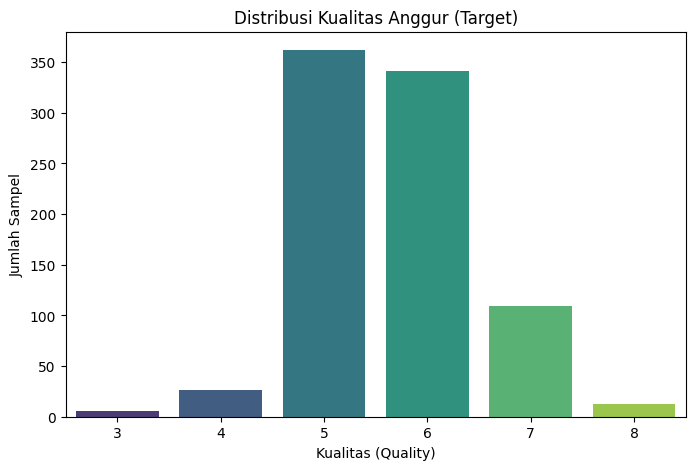

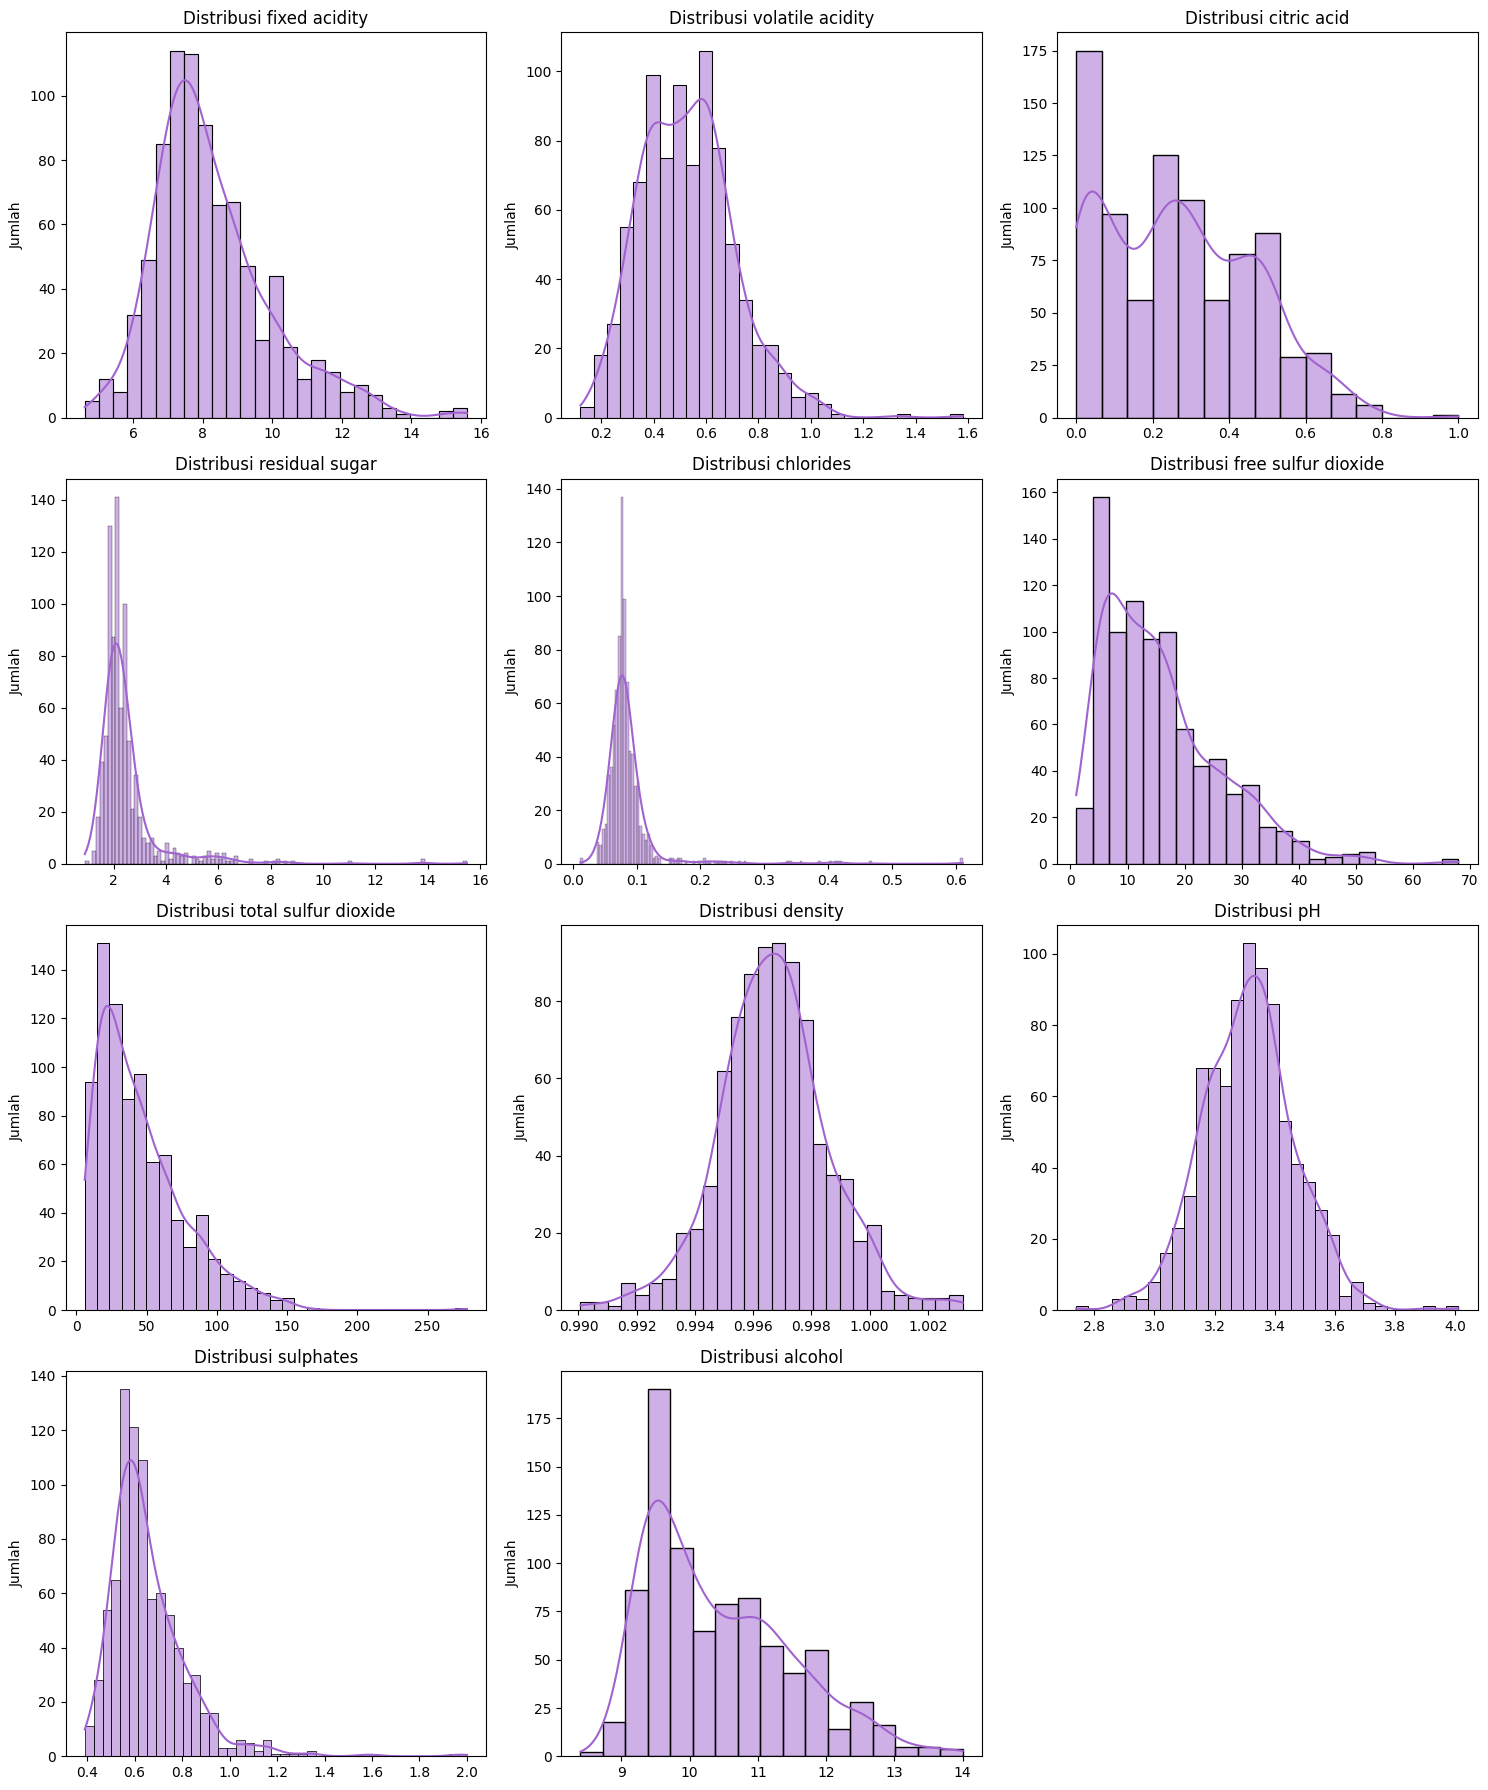

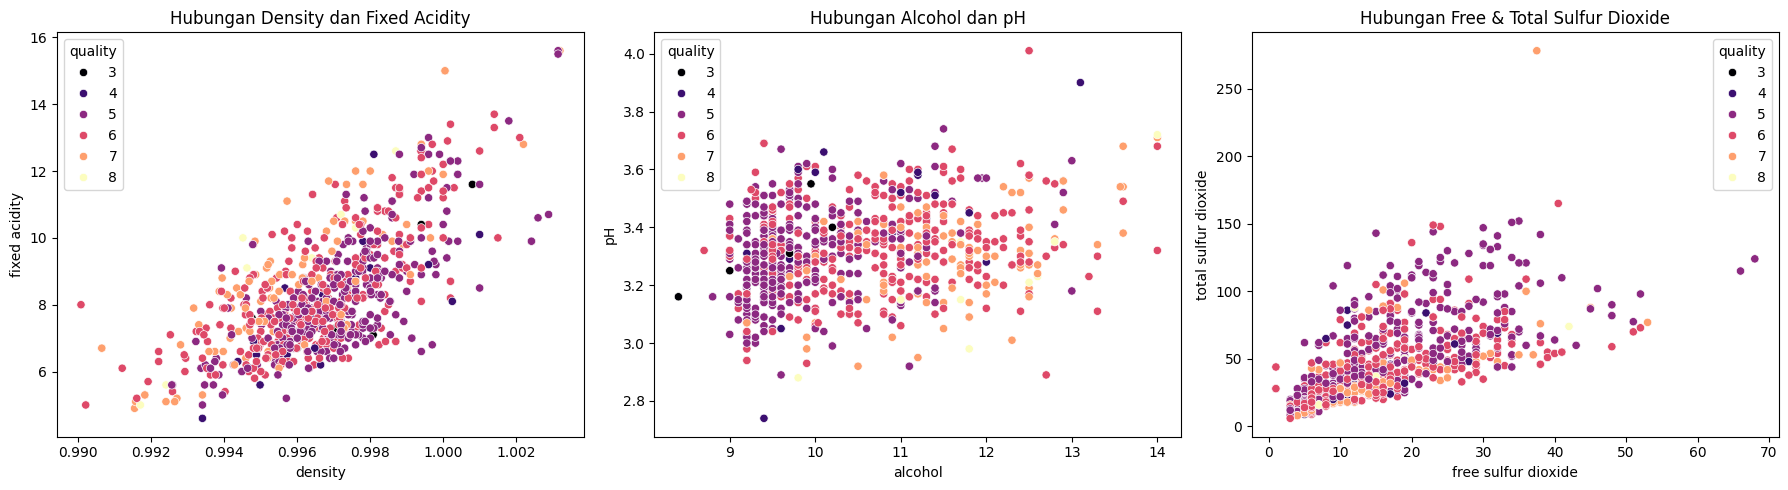

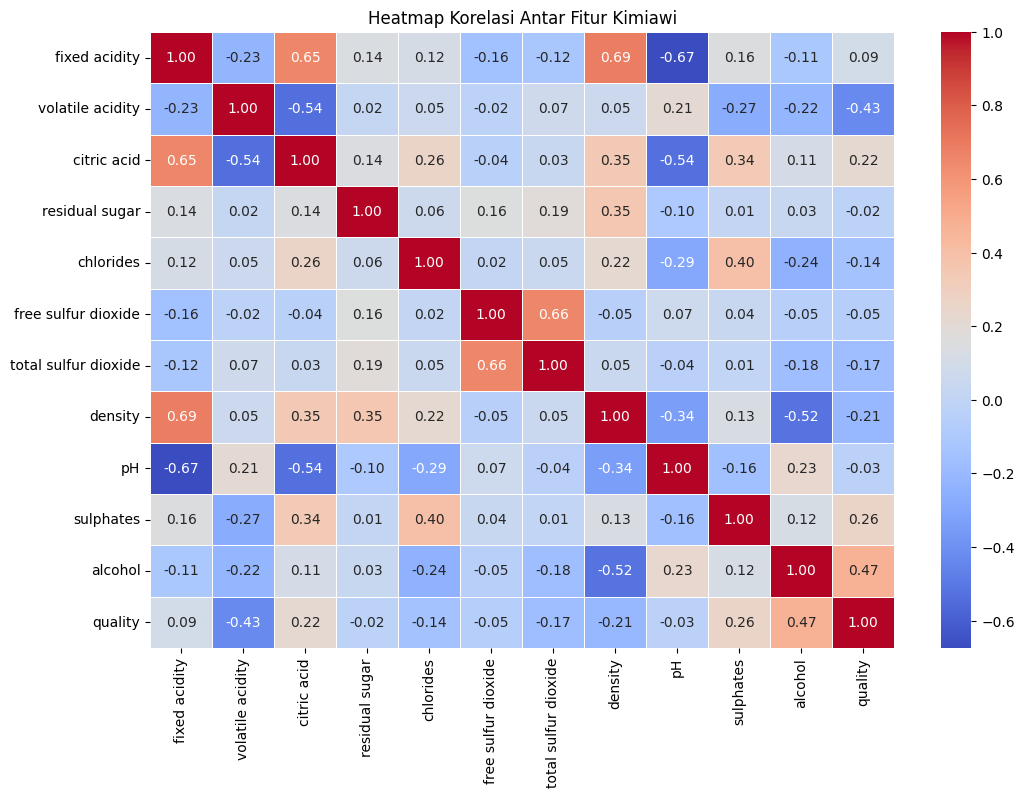

In [1]:
# ==============================================================================
# 1. IMPORT LIBRARY LENGKAP
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Library Tambahan untuk Persiapan Data, Modeling, dan Evaluasi (Tahap Selanjutnya)
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================================================================
# 2. MEMUAT DATASET
# ==============================================================================
base_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality'
df_train = pd.read_csv(f'{base_path}/data_training.csv')
df_test = pd.read_csv(f'{base_path}/data_testing.csv')

# ==============================================================================
# 3. INSPEKSI AWAL & PENGECEKAN MISSING VALUES
# ==============================================================================
print("=== INFO DATA TRAINING ===")
print(df_train.info())
print("\n=== 5 BARIS PERTAMA DATA TRAINING ===")
display(df_train.head())

print("\n=== PENGECEKAN MISSING VALUES ===")
missing_train = df_train.isnull().sum()
if missing_train.sum() > 0:
    print(missing_train[missing_train > 0])
else:
    print("Tidak ada missing values pada Data Training. Data bersih.")

# ==============================================================================
# 4. VISUALISASI DISTRIBUSI TARGET (QUALITY)
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df_train, palette='viridis')
plt.title('Distribusi Kualitas Anggur (Target)')
plt.xlabel('Kualitas (Quality)')
plt.ylabel('Jumlah Sampel')
plt.show()

# ==============================================================================
# 5. VISUALISASI DISTRIBUSI FITUR KIMIAWI (HISTOGRAM & KDE)
# ==============================================================================
# Mengambil daftar kolom numerik (kecuali Id dan quality)
fitur_numerik = df_train.drop(columns=['Id', 'quality']).columns.tolist()

# Membuat grid subplots (4 baris x 3 kolom) untuk menampung 11 fitur
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 18))

for col, ax in zip(fitur_numerik, axs.flat):
    # sns.histplot dengan kde=True untuk melihat kurva distribusi normal
    sns.histplot(data=df_train, x=col, kde=True, ax=ax, color="#A163CF")
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Jumlah')

# Menghapus subplot kosong terakhir karena kita hanya punya 11 fitur untuk 12 slot
if len(fitur_numerik) < len(axs.flat):
    for i in range(len(fitur_numerik), len(axs.flat)):
        fig.delaxes(axs.flat[i])

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. VISUALISASI HUBUNGAN ANTAR FITUR (SCATTER PLOTS)
# ==============================================================================
# Membuat 3 sebaran grafik untuk menganalisis hubungan antar variabel kimiawi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Density vs Fixed Acidity
sns.scatterplot(ax=axes[0], x="density", y="fixed acidity", hue="quality", palette="magma", data=df_train)
axes[0].set_title("Hubungan Density dan Fixed Acidity")

# Plot 2: Alcohol vs pH
sns.scatterplot(ax=axes[1], x="alcohol", y="pH", hue="quality", palette="magma", data=df_train)
axes[1].set_title("Hubungan Alcohol dan pH")

# Plot 3: Free Sulfur Dioxide vs Total Sulfur Dioxide
sns.scatterplot(ax=axes[2], x="free sulfur dioxide", y="total sulfur dioxide", hue="quality", palette="magma", data=df_train)
axes[2].set_title("Hubungan Free & Total Sulfur Dioxide")

plt.tight_layout()
plt.show()

# ==============================================================================
# 7. HEATMAP KORELASI KESELURUHAN
# ==============================================================================
plt.figure(figsize=(12, 8))
correlation_matrix = df_train.drop('Id', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Kimiawi')
plt.show()

# Data Preparation

In [2]:
# ==============================================================================
# 1. IMPORT LIBRARY 
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# ==============================================================================
# 2. MEMISAHKAN FITUR (X) DAN TARGET (y)
# ==============================================================================
# Membuang kolom 'Id' dan 'quality' dari X
X = df_train.drop(columns=['Id', 'quality'])
y = df_train['quality']

# ==============================================================================
# 3. LABEL ENCODING (Syarat Wajib Ensemble)
# ==============================================================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("=== MAPPING KELAS TARGET ===")
mapping_kelas = dict(zip(le.classes_, le.transform(le.classes_)))
for asli, encoded in mapping_kelas.items():
    print(f"Kualitas Asli: {asli} -> Kode Mesin: {encoded}")

# ==============================================================================
# 4. MEMBAGI DATA (TRAIN-VALIDATION SPLIT)
# ==============================================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==============================================================================
# 5. PENANGANAN DATA TIDAK SEIMBANG (SMOTE) DENGAN PENYESUAIAN NEIGHBORS
# ==============================================================================
# Mencari jumlah sampel paling sedikit dari seluruh kelas di data latih
min_samples_in_class = pd.Series(y_train).value_counts().min()

# SMOTE membutuhkan k_neighbors < jumlah sampel di kelas minoritas.
# Nilai default k_neighbors adalah 5. Kita sesuaikan agar tidak melebihi batas.
k_neighbors_dinamis = min(5, min_samples_in_class - 1)

print(f"\nJumlah sampel terkecil di kelas minoritas (Train): {min_samples_in_class}")
print(f"Menggunakan k_neighbors = {k_neighbors_dinamis} untuk SMOTE.")

# Menerapkan SMOTE dengan k_neighbors yang sudah disesuaikan
smote = SMOTE(k_neighbors=k_neighbors_dinamis, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ==============================================================================
# 6. NORMALISASI FITUR (MIN-MAX SCALING)
# ==============================================================================
# Menggunakan MinMaxScaler karena dari tahapan EDA terbukti data tidak terdistribusi normal
scaler = MinMaxScaler(feature_range=(0, 1))

# Lakukan fit_transform HANYA pada data latih untuk mencegah Data Leakage
X_train_scaled = scaler.fit_transform(X_train_smote)
# Data validasi hanya di-transform berdasarkan perhitungan data latih
X_val_scaled = scaler.transform(X_val)

# ==============================================================================
# 7. VERIFIKASI DIMENSI DATA
# ==============================================================================
print("\n=== DIMENSI DATA SEBELUM & SESUDAH PROSES ===")
print(f"Jumlah data latih awal: {X_train.shape[0]} baris")
print(f"Jumlah data latih setelah SMOTE: {X_train_scaled.shape[0]} baris")
print(f"Jumlah data validasi murni: {X_val_scaled.shape[0]} baris")

=== MAPPING KELAS TARGET ===
Kualitas Asli: 3 -> Kode Mesin: 0
Kualitas Asli: 4 -> Kode Mesin: 1
Kualitas Asli: 5 -> Kode Mesin: 2
Kualitas Asli: 6 -> Kode Mesin: 3
Kualitas Asli: 7 -> Kode Mesin: 4
Kualitas Asli: 8 -> Kode Mesin: 5

Jumlah sampel terkecil di kelas minoritas (Train): 5
Menggunakan k_neighbors = 4 untuk SMOTE.

=== DIMENSI DATA SEBELUM & SESUDAH PROSES ===
Jumlah data latih awal: 685 baris
Jumlah data latih setelah SMOTE: 1734 baris
Jumlah data validasi murni: 172 baris


# Feature Engineering

In [3]:
# ==============================================================================
# TAHAP TAMBAHAN: FEATURE ENGINEERING (REKAYASA FITUR)
# ==============================================================================
print("=== MULAI PROSES FEATURE ENGINEERING ===")

def rekayasa_fitur_kimiawi(df):
    """
    Fungsi untuk membuat fitur prediktif baru berdasarkan interaksi 
    antar variabel kimiawi anggur.
    """
    df_engineered = df.copy()
    
    # 1. Rasio Alkohol dan Volatile Acidity 
    # (Dua fitur dengan korelasi tertinggi positif dan negatif terhadap target)
    df_engineered['alcohol_volatile_ratio'] = df_engineered['alcohol'] / df_engineered['volatile acidity']
    
    # 2. Bound Sulfur Dioxide (Sulfur Terikat)
    # (Diekstrak karena korelasi tinggi antara total dan free sulfur dioxide)
    df_engineered['bound_sulfur_dioxide'] = df_engineered['total sulfur dioxide'] - df_engineered['free sulfur dioxide']
    
    # 3. Total Acidity (Total Keasaman)
    # (Kombinasi dari 3 jenis asam yang ada di dalam anggur)
    df_engineered['total_acidity'] = df_engineered['fixed acidity'] + df_engineered['volatile acidity'] + df_engineered['citric acid']
    
    # 4. Rasio Manis-Asam (Sugar to Acid Ratio)
    # (Keseimbangan rasa yang sering menjadi penentu utama kualitas anggur)
    df_engineered['sugar_acid_ratio'] = df_engineered['residual sugar'] / df_engineered['total_acidity']
    
    return df_engineered

# Menerapkan fungsi pada Data Latih dan Data Uji secara paralel
# Kita simpan ke dalam variabel baru (df_train_eng dan df_test_eng)
df_train_eng = rekayasa_fitur_kimiawi(df_train)
df_test_eng = rekayasa_fitur_kimiawi(df_test)

# Memverifikasi penambahan dimensi kolom
print(f"Jumlah kolom awal (termasuk Id & Target): {df_train.shape[1]}")
print(f"Jumlah kolom setelah rekayasa fitur: {df_train_eng.shape[1]}")

print("\n=== PRATINJAU DATA SETELAH FEATURE ENGINEERING ===")
# Menampilkan 5 baris pertama dengan fokus pada 4 fitur baru di kolom paling kanan
display(df_train_eng.head())

=== MULAI PROSES FEATURE ENGINEERING ===
Jumlah kolom awal (termasuk Id & Target): 13
Jumlah kolom setelah rekayasa fitur: 17

=== PRATINJAU DATA SETELAH FEATURE ENGINEERING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,alcohol_volatile_ratio,bound_sulfur_dioxide,total_acidity,sugar_acid_ratio
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366,13.243243,35.0,8.120,0.209360
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103,16.000000,53.0,8.895,0.236088
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942,23.255814,39.0,10.930,0.237877
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811,21.800000,17.0,13.950,0.200717
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918,30.555556,47.0,9.080,0.242291


# Fitur Pruning

# Pembuatan Model & Hyperparameter Tuning (dengan Optuna)

# K-Fold Validation

# Pseudo-Labeling

# Evaluasi Model

# Prediksi Data Uji (Testing)